# Qubit Decoherence Analysis

This notebook demonstrates two analysis workflows on qubit decoherence data:

1. **QubitDecoherenceAnalyzer** — fits $\rho_{11}(t)$ and $\rho_{10}(t)$ to the non-Markovian amplitude-damping model to extract $\Gamma$ and $\Lambda$.
2. **HankelAnalyzer** — extracts frequency modes from the signal via Hankel matrix SVD decomposition (MPM/HSVD).

Data can be loaded from an **experiment file** (Section 1A) or **simulated** from the analytic model with added noise (Section 1B). Run **one** of the two cells to produce the `dataset` variable used by subsequent analysis.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from scqat.protocols.qubit_decoherence import (
    QubitDecoherenceAnalyzer,
    _rho11_model,
    _rho10_model,
)
from scqat.protocols.hankel_analysis import HankelAnalyzer
from scqat.parsers.xarray_h5_parser import load_xarray_h5
import os
from scqat.parsers.qualibrate_parser import repetition_data, parse_timestamp

## 1B. Generate Simulated Data

Create synthetic $\rho_{11}(t)$ and $\rho_{10}(t)$ traces from the analytic model with additive Gaussian noise. Adjust the parameters below to explore different damping regimes.

In [2]:
# --- Simulation parameters ---
Gamma_true = 2      # relaxation rate
Lambda_true = 0.10     # spectral width
rho11_0 = 1.0         # initial excited-state population
rho10_0 = 0.5         # initial off-diagonal coherence
noise_std = 0.02       # standard deviation of Gaussian noise
n_points = 200         # number of time samples
t_max = 10.0           # maximum time

rng = np.random.default_rng(42)
t = np.linspace(0, t_max, n_points)

rho11_clean = _rho11_model(t, Gamma_true, Lambda_true, rho11_0)
rho10_clean = _rho10_model(t, Gamma_true, Lambda_true, rho10_0)

rho11_noisy = rho11_clean + rng.normal(0, noise_std, size=n_points)
rho10_noisy = rho10_clean + rng.normal(0, noise_std, size=n_points)

dataset = xr.Dataset(
    {
        "rho_11": ("time", rho11_noisy),
        "rho_10": ("time", rho10_noisy),
    },
    coords={"time": t},
    attrs={
        "source": "simulation",
        "Gamma_true": Gamma_true,
        "Lambda_true": Lambda_true,
    },
)
dataset

<xarray.Dataset> Size: 5kB
Dimensions:  (time: 200)
Coordinates:
  * time     (time) float64 2kB 0.0 0.05025 0.1005 0.1508 ... 9.899 9.95 10.0
Data variables:
    rho_11   (time) float64 2kB 1.006 0.9789 1.014 ... 0.3568 0.3651 0.3622
    rho_10   (time) float64 2kB 0.5068 0.5281 0.5016 ... -0.2974 -0.2915 -0.3164
Attributes:
    source:       simulation
    Gamma_true:   2
    Lambda_true:  0.1

## 2. Quick Look at the Data

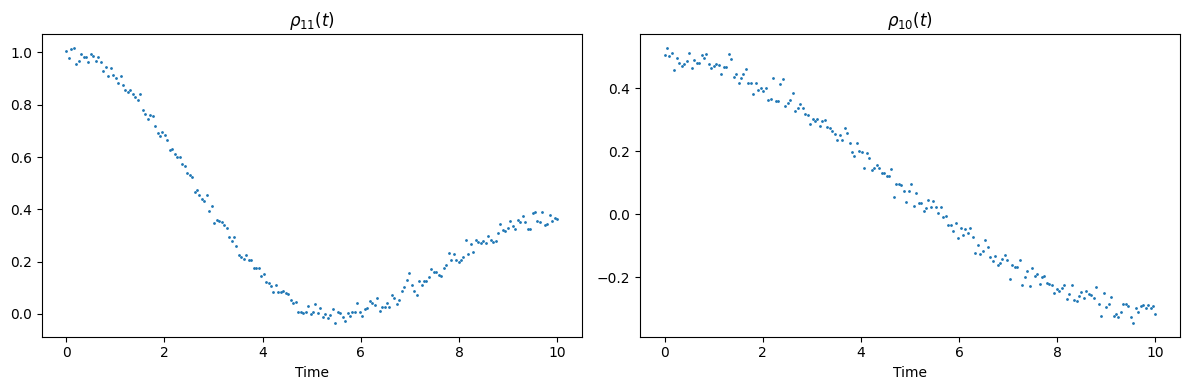

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if "rho_11" in dataset.data_vars:
    axes[0].plot(dataset.coords["time"], dataset["rho_11"], ".", ms=2)
    axes[0].set_title(r"$\rho_{11}(t)$")
    axes[0].set_xlabel("Time")

if "rho_10" in dataset.data_vars:
    axes[1].plot(dataset.coords["time"], dataset["rho_10"], ".", ms=2)
    axes[1].set_title(r"$\rho_{10}(t)$")
    axes[1].set_xlabel("Time")

fig.tight_layout()
plt.show()

---
## 3. Qubit Decoherence Analysis

Fit $\rho_{11}(t)$ and $\rho_{10}(t)$ to the non-Markovian amplitude-damping model to extract $\Gamma$ (relaxation rate) and $\Lambda$ (spectral width).

In [4]:
decoherence_analyzer = QubitDecoherenceAnalyzer()
decoherence_results, decoherence_figs = decoherence_analyzer.analyze(dataset)
plt.close('all')

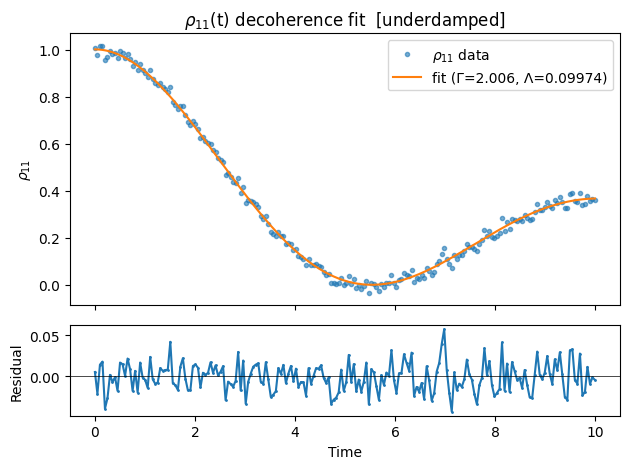

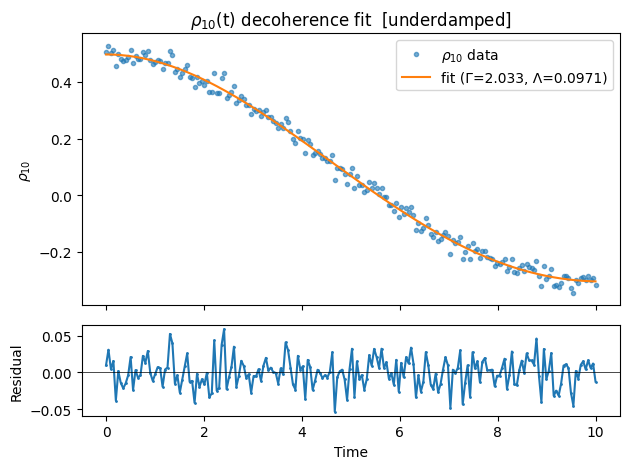

In [5]:
for name, fig in decoherence_figs.items():
    display(fig)
    plt.close(fig)

In [6]:
for var_name, res in decoherence_results.items():
    print(f"=== {var_name} ===")
    print(f"  Gamma  = {res['Gamma']:.6f} ± {res['Gamma_err']:.6f}")
    print(f"  Lambda = {res['Lambda']:.6f} ± {res['Lambda_err']:.6f}")
    print(f"  rho_0  = {res['rho_0']:.6f} ± {res['rho_0_err']:.6f}")
    print(f"  d      = {res['d']}")
    print(f"  regime = {res['regime']}")
    print()

=== rho_11 ===
  Gamma  = 2.005868 ± 0.019389
  Lambda = 0.099740 ± 0.001471
  rho_0  = 1.000866 ± 0.003199
  d      = 0.6246461462480835j
  regime = underdamped

=== rho_10 ===
  Gamma  = 2.033072 ± 0.058163
  Lambda = 0.097104 ± 0.003817
  rho_0  = 0.497204 ± 0.003106
  d      = 0.6208148197645564j
  regime = underdamped



---
## 4. Hankel Analysis

Use the Hankel matrix SVD (Matrix Pencil Method) to extract modal frequencies, decay rates, and amplitudes from one of the decoherence signals.

The `HankelAnalyzer` expects a `signal` data variable, so we repackage the chosen trace into the required format.

In [7]:
# Choose which variable to analyze with Hankel (rho_10 preferred as it
# retains the oscillatory / phase information; fall back to rho_11)

signal_var = "rho_11"

if signal_var in dataset.data_vars:
    print(f"Using {signal_var} for Hankel analysis.")
else:
    raise ValueError("No suitable signal variable found in dataset.")

hankel_dataset = xr.Dataset(
    {"signal": ("time", dataset[signal_var].values)},
    coords={"time": dataset.coords["time"].values},
)

print(f"Hankel analysis will use '{signal_var}' as the signal.")
hankel_dataset

Using rho_11 for Hankel analysis.
Hankel analysis will use 'rho_11' as the signal.


<xarray.Dataset> Size: 3kB
Dimensions:  (time: 200)
Coordinates:
  * time     (time) float64 2kB 0.0 0.05025 0.1005 0.1508 ... 9.899 9.95 10.0
Data variables:
    signal   (time) float64 2kB 1.006 0.9789 1.014 ... 0.3568 0.3651 0.3622

In [8]:
# --- HankelAnalyzer parameters ---
mode_method = "relative"    # 'relative', 'absolute', or 'energy'
threshold = 2e-1            # for 'relative' (ratio to largest SV) or 'absolute'
energy_target = 0.95        # for 'energy' method
recon_method = "mpm"        # 'mpm' or 'hsvd'
eigval_threshold = 1e-3     # minimum eigenvalue magnitude to keep

hankel_analyzer = HankelAnalyzer()
hankel_results, hankel_figs = hankel_analyzer.analyze(
    hankel_dataset,
    mode_method=mode_method,
    recon_method=recon_method,
    threshold=threshold,
    energy_target=energy_target,
    eigval_threshold=eigval_threshold,
)
plt.close('all')

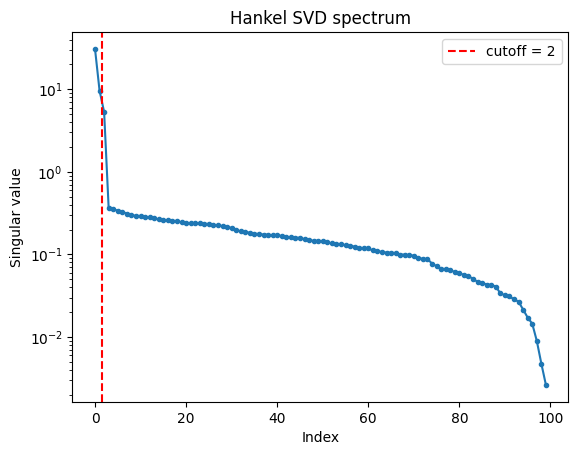

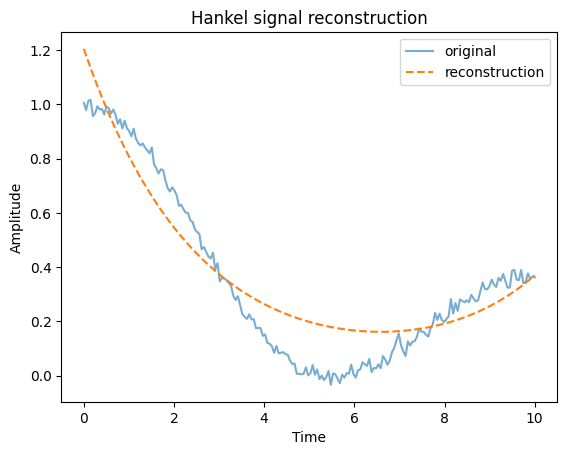

In [9]:
for name, fig in hankel_figs.items():
    display(fig)
    plt.close(fig)

In [10]:
print(f"Number of modes retained: {hankel_results['n_modes']}\n")
for i, mode in enumerate(hankel_results["modes"]):
    print(f"Mode {i}:")
    print(f"  frequency    = {mode['freq_hz']:.6g} Hz")
    print(f"  decay rate   = {mode['decay_rate']:.6g}")
    print(f"  time const.  = {mode['time_constant']:.6g}")
    print(f"  amplitude    = {mode['amplitude']:.6g}")
    print(f"  phase        = {mode['phase']:.4f} rad")
    print()

Number of modes retained: 2

Mode 0:
  frequency    = -2.84181e-34 Hz
  decay rate   = -0.403234
  time const.  = 2.47995
  amplitude    = 1.20065
  phase        = 0.0000 rad

Mode 1:
  frequency    = -3.24197e-34 Hz
  decay rate   = 0.441437
  time const.  = inf
  amplitude    = 0.00421725
  phase        = 0.0000 rad

